# Лабораторная работа 5: Классификация (Вариант 3)

## Обнаружение мошеннических транзакций в электронной коммерции

### Цель работы
Изучение алгоритмов и методов классификации на практике. Разработка предсказательной модели для определения мошеннических транзакций в электронной коммерции используя методы:
- Метод k-ближайших соседей (KNeighborsClassifier)
- Дерево решений (DecisionTreeClassifier)
- Логистическая регрессия (LogisticRegression)
- Случайный лес (RandomForestClassifier)

### Описание набора данных
Набор данных содержит информацию о 3024 транзакциях электронной коммерции с 11 признаками и целевым классом (мошенническая или нормальная).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier, export_text, export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
    roc_auc_score,
    classification_report
)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## Загрузка и первичный анализ данных

Происходит загрузка файла, описание его признаков, а также предварительная обработка:

In [2]:
df = pd.read_csv('C:\\Users\\vanya\\Downloads\\ecommerce_fraud.csv')

print('Форма датасета:', df.shape)
print('\nПервые 5 строк датасета:')
print(df.head())
print('\nТипы данных:')
print(df.dtypes)
print('\nОписательная статистика:')
print(df.describe())

Форма датасета: (3024, 12)

Первые 5 строк датасета:
   transaction_amount device_type browser payment_method country  num_items  \
0               62.18     Desktop  Safari            COD      UK          3   
1               28.16     Desktop  Chrome            COD      US          2   
2               17.57      Mobile  Chrome           Card      DE          1   
3               61.61     Desktop  Safari         PayPal   Other          4   
4                4.28     Desktop    Edge           Card      BR          7   

   time_on_site_sec is_first_purchase referral  hour_of_day  account_age_days  \
0              58.0                No   Direct           15               808   
1              75.0               Yes   Direct           10               753   
2             101.0                No   Social           21              1017   
3              63.0               Yes   Search           20              1146   
4             399.0                No   Direct            4        

In [5]:
print('Пропущенные значения:')
print(df.isnull().sum())
print('\nОбщее количество пропусков:', df.isnull().sum().sum())

print('\nРаспределение целевого класса (Fraud):')
print(df['Fraud'].value_counts())
print('\nПроцент мошеннических транзакций:', 
      f"{(df['Fraud'].sum() / len(df) * 100):.2f}%")

Пропущенные значения:
transaction_amount    0
device_type           0
browser               0
payment_method        0
country               0
num_items             0
time_on_site_sec      0
is_first_purchase     0
referral              0
hour_of_day           0
account_age_days      0
Fraud                 0
dtype: int64

Общее количество пропусков: 0

Распределение целевого класса (Fraud):
Fraud
0    2889
1     135
Name: count, dtype: int64

Процент мошеннических транзакций: 4.46%


In [6]:
print('Уникальные значения категориальных признаков:')
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"{col}: {sorted(df[col].unique())}")

print('\nЧисленные признаки (числовые):')
numeric_cols = df.select_dtypes(include=[np.number]).columns
print(list(numeric_cols))

Уникальные значения категориальных признаков:
device_type: ['Desktop', 'Mobile', 'Tablet']
browser: ['Chrome', 'Edge', 'Firefox', 'Other', 'Safari']
payment_method: ['BankTransfer', 'COD', 'Card', 'PayPal']
country: ['BR', 'CN', 'DE', 'FR', 'IN', 'Other', 'UK', 'US']
is_first_purchase: ['No', 'Yes']
referral: ['Ads', 'Direct', 'Search', 'Social']

Численные признаки (числовые):
['transaction_amount', 'num_items', 'time_on_site_sec', 'hour_of_day', 'account_age_days', 'Fraud']


## 2. Построение матрицы диаграмм рассеяния

Выделим значения целевой переменной разными цветами для визуализации их распределения.

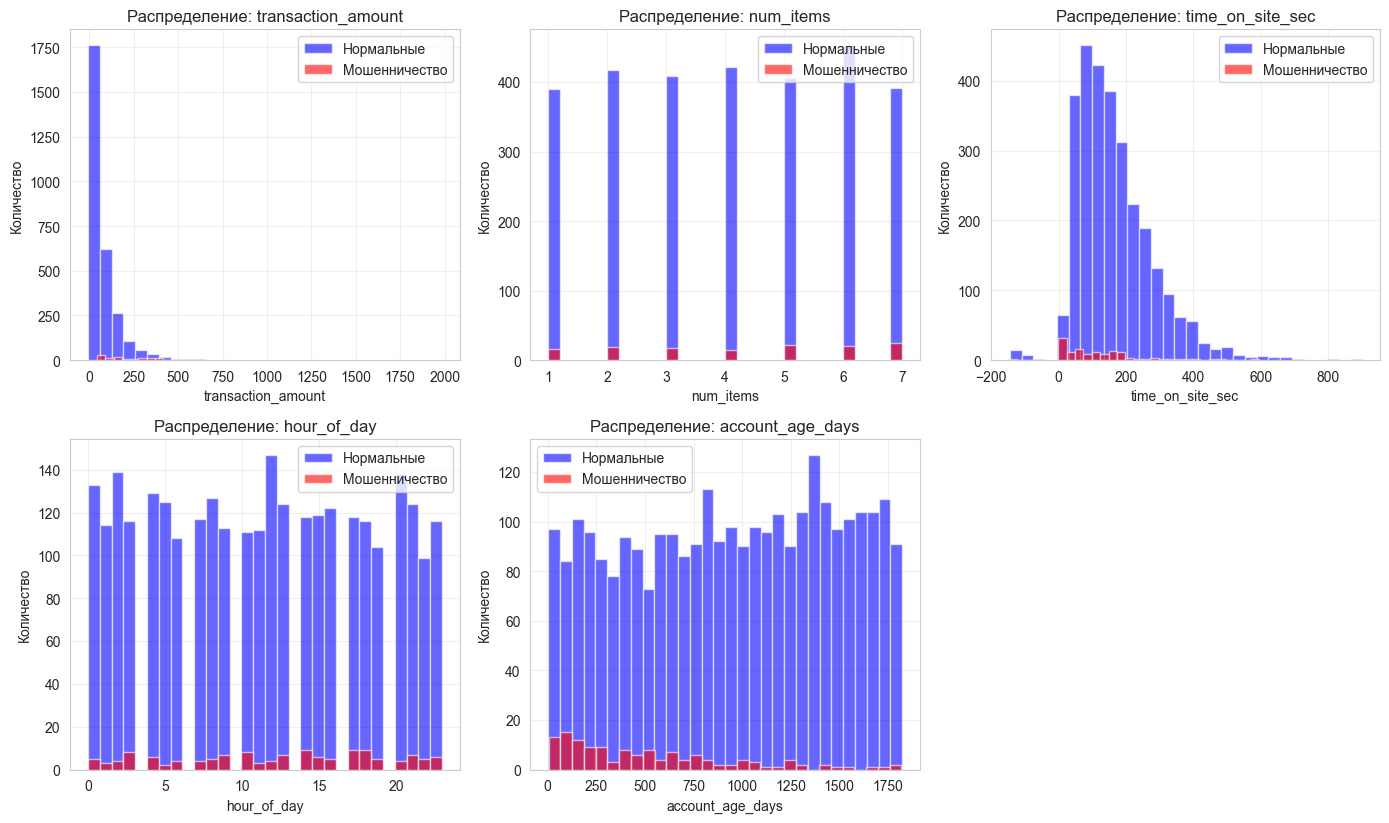

Матрица диаграмм распределения численных признаков по классам построена.


In [7]:
target = df['Fraud']
numeric_features = df.select_dtypes(include=[np.number]).drop('Fraud', axis=1)

data_for_scatter = numeric_features.copy()
data_for_scatter['Fraud'] = target

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

numeric_cols = list(numeric_features.columns)
for idx, col in enumerate(numeric_cols):
    normal = data_for_scatter[data_for_scatter['Fraud'] == 0][col]
    fraud = data_for_scatter[data_for_scatter['Fraud'] == 1][col]
    
    axes[idx].hist(normal, bins=30, alpha=0.6, label='Нормальные', color='blue')
    axes[idx].hist(fraud, bins=30, alpha=0.6, label='Мошенничество', color='red')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Количество')
    axes[idx].set_title(f'Распределение: {col}')
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()
print('Матрица диаграмм распределения численных признаков по классам построена.')

## 3. Предварительная обработка данных (нормализация и стандартизация)

Перед предсказанием необходимо провести обработку данных, которая включает в себя: введение численных признаков вместо строковых, определение размера выборки для обучения, а также нормализацию и стандартизацию.

In [8]:
df_processed = df.copy()
categorical_features = df_processed.select_dtypes(include='object').columns.tolist()
print(f'Категориальные признаки: {categorical_features}')
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_processed[categorical_features] = encoder.fit_transform(df_processed[categorical_features])

print('\nДанные после кодирования категориальных признаков:')
print(df_processed.dtypes)
print('\nПервые 5 строк после обработки:')
print(df_processed.head())

Категориальные признаки: ['device_type', 'browser', 'payment_method', 'country', 'is_first_purchase', 'referral']

Данные после кодирования категориальных признаков:
transaction_amount    float64
device_type           float64
browser               float64
payment_method        float64
country               float64
num_items               int64
time_on_site_sec      float64
is_first_purchase     float64
referral              float64
hour_of_day             int64
account_age_days        int64
Fraud                   int64
dtype: object

Первые 5 строк после обработки:
   transaction_amount  device_type  browser  payment_method  country  \
0               62.18          0.0      4.0             1.0      6.0   
1               28.16          0.0      0.0             1.0      7.0   
2               17.57          1.0      0.0             2.0      2.0   
3               61.61          0.0      4.0             3.0      5.0   
4                4.28          0.0      1.0             2.0      0.

In [9]:
X = df_processed.drop('Fraud', axis=1)
y = df_processed['Fraud']

print(f'Размер матрицы признаков X: {X.shape}')
print(f'Размер вектора целевой переменной y: {y.shape}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=0, 
    stratify=y  
)

print('\nОбучающая выборка:')
print(f'  X_train размер: {X_train.shape}')
print(f'  y_train размер: {y_train.shape}')
print('\nТестовая выборка:')
print(f'  X_test размер: {X_test.shape}')
print(f'  y_test размер: {y_test.shape}')
print('\nРаспределение классов в обучающей выборке:')
print(y_train.value_counts())
print('\nРаспределение классов в тестовой выборке:')
print(y_test.value_counts())

Размер матрицы признаков X: (3024, 11)
Размер вектора целевой переменной y: (3024,)

Обучающая выборка:
  X_train размер: (2116, 11)
  y_train размер: (2116,)

Тестовая выборка:
  X_test размер: (908, 11)
  y_test размер: (908,)

Распределение классов в обучающей выборке:
Fraud
0    2022
1      94
Name: count, dtype: int64

Распределение классов в тестовой выборке:
Fraud
0    867
1     41
Name: count, dtype: int64


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print('Данные после стандартизации:')
print('\nСредние значения признаков (должны быть близки к 0):')
print(X_train_scaled.mean())
print('\nСтандартные отклонения признаков (должны быть близки к 1):')
print(X_train_scaled.std())

Данные после стандартизации:

Средние значения признаков (должны быть близки к 0):
transaction_amount    4.260402e-17
device_type           7.387495e-17
browser               6.044314e-17
payment_method        1.410340e-16
country               6.967751e-17
num_items             8.394881e-17
time_on_site_sec     -8.059086e-17
is_first_purchase    -3.357952e-17
referral              2.854260e-17
hour_of_day           8.394881e-18
account_age_days      9.150420e-17
dtype: float64

Стандартные отклонения признаков (должны быть близки к 1):
transaction_amount    1.000236
device_type           1.000236
browser               1.000236
payment_method        1.000236
country               1.000236
num_items             1.000236
time_on_site_sec      1.000236
is_first_purchase     1.000236
referral              1.000236
hour_of_day           1.000236
account_age_days      1.000236
dtype: float64


## 4. Обучение и оценка моделей классификации

Используется 4 алгоритма классификации (дерево решений, случайный лес, логическая регрессия и k- ближайших соседей). Для каждого из алгоритмов рассчитываются метрики качества (precision, recall, f1-score, support, accurancy, marco_avg и weight_avg). Для этого создается вспомогательная функция рассчета метрик для каждого из случаев

In [11]:
models_results = {}
def calculate_metrics(y_true, y_pred, y_pred_proba=None):
    """
    Функция для вычисления всех необходимых метрик качества классификации.
    
    Параметры:
    - y_true: истинные значения целевой переменной
    - y_pred: предсказанные классы моделью
    - y_pred_proba: вероятности принадлежности к классу 1 (используется для ROC AUC)
    
    Возвращает словарь с метриками.
    """
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1 Score': f1_score(y_true, y_pred, zero_division=0),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred)
    }
    if y_pred_proba is not None:
        metrics['ROC AUC'] = roc_auc_score(y_true, y_pred_proba)
    
    return metrics

print('Функция для расчёта метрик определена.')

Функция для расчёта метрик определена.


In [12]:
print('1. МЕТОД K-БЛИЖАЙШИХ СОСЕДЕЙ (KNeighborsClassifier)')

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)
knn_proba = knn.predict_proba(X_test_scaled)[:, 1]

knn_metrics = calculate_metrics(y_test, knn_pred, knn_proba)
models_results['KNN'] = knn_metrics

print('\nМетрики качества для KNN:')
for metric_name, metric_value in knn_metrics.items():
    print(f'  {metric_name}: {metric_value:.4f}')

knn_cm = confusion_matrix(y_test, knn_pred)
print('\nМатрица ошибок (Confusion Matrix):')
print(knn_cm)
print('\nОтчёт классификации:')
print(classification_report(y_test, knn_pred, zero_division=0))

1. МЕТОД K-БЛИЖАЙШИХ СОСЕДЕЙ (KNeighborsClassifier)

Метрики качества для KNN:
  Accuracy: 0.9493
  Precision: 0.3077
  Recall: 0.0976
  F1 Score: 0.1481
  Balanced Accuracy: 0.5436
  ROC AUC: 0.6566

Матрица ошибок (Confusion Matrix):
[[858   9]
 [ 37   4]]

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.96      0.99      0.97       867
           1       0.31      0.10      0.15        41

    accuracy                           0.95       908
   macro avg       0.63      0.54      0.56       908
weighted avg       0.93      0.95      0.94       908



In [13]:
print('2. ДЕРЕВО РЕШЕНИЙ (DecisionTreeClassifier)')
dt = DecisionTreeClassifier(max_depth=10, random_state=42)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)
dt_proba = dt.predict_proba(X_test_scaled)[:, 1]
dt_metrics = calculate_metrics(y_test, dt_pred, dt_proba)
models_results['DecisionTree'] = dt_metrics

print('\nМетрики качества для дерева решений:')
for metric_name, metric_value in dt_metrics.items():
    print(f'  {metric_name}: {metric_value:.4f}')

dt_cm = confusion_matrix(y_test, dt_pred)
print('\nМатрица ошибок (Confusion Matrix):')
print(dt_cm)
print('\nОтчёт классификации:')
print(classification_report(y_test, dt_pred, zero_division=0))

2. ДЕРЕВО РЕШЕНИЙ (DecisionTreeClassifier)

Метрики качества для дерева решений:
  Accuracy: 0.9405
  Precision: 0.3488
  Recall: 0.3659
  F1 Score: 0.3571
  Balanced Accuracy: 0.6668
  ROC AUC: 0.6851

Матрица ошибок (Confusion Matrix):
[[839  28]
 [ 26  15]]

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       867
           1       0.35      0.37      0.36        41

    accuracy                           0.94       908
   macro avg       0.66      0.67      0.66       908
weighted avg       0.94      0.94      0.94       908



In [14]:
print('3. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (LogisticRegression)')
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)
lr_proba = lr.predict_proba(X_test_scaled)[:, 1]
lr_metrics = calculate_metrics(y_test, lr_pred, lr_proba)
models_results['LogisticRegression'] = lr_metrics
print('\nМетрики качества для логистической регрессии:')
for metric_name, metric_value in lr_metrics.items():
    print(f'  {metric_name}: {metric_value:.4f}')

lr_cm = confusion_matrix(y_test, lr_pred)
print('\nМатрица ошибок (Confusion Matrix):')
print(lr_cm)
print('\nОтчёт классификации:')
print(classification_report(y_test, lr_pred, zero_division=0))

3. ЛОГИСТИЧЕСКАЯ РЕГРЕССИЯ (LogisticRegression)

Метрики качества для логистической регрессии:
  Accuracy: 0.9548
  Precision: 0.5000
  Recall: 0.0976
  F1 Score: 0.1633
  Balanced Accuracy: 0.5465
  ROC AUC: 0.8964

Матрица ошибок (Confusion Matrix):
[[863   4]
 [ 37   4]]

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       867
           1       0.50      0.10      0.16        41

    accuracy                           0.95       908
   macro avg       0.73      0.55      0.57       908
weighted avg       0.94      0.95      0.94       908



In [15]:
print('4. СЛУЧАЙНЫЙ ЛЕС (RandomForestClassifier)')
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
rf_proba = rf.predict_proba(X_test_scaled)[:, 1]
rf_metrics = calculate_metrics(y_test, rf_pred, rf_proba)
models_results['RandomForest'] = rf_metrics

print('\nМетрики качества для случайного леса:')
for metric_name, metric_value in rf_metrics.items():
    print(f'  {metric_name}: {metric_value:.4f}')

rf_cm = confusion_matrix(y_test, rf_pred)
print('\nМатрица ошибок (Confusion Matrix):')
print(rf_cm)
print('\nОтчёт классификации:')
print(classification_report(y_test, rf_pred, zero_division=0))

4. СЛУЧАЙНЫЙ ЛЕС (RandomForestClassifier)

Метрики качества для случайного леса:
  Accuracy: 0.9570
  Precision: 0.5833
  Recall: 0.1707
  F1 Score: 0.2642
  Balanced Accuracy: 0.5825
  ROC AUC: 0.8470

Матрица ошибок (Confusion Matrix):
[[862   5]
 [ 34   7]]

Отчёт классификации:
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       867
           1       0.58      0.17      0.26        41

    accuracy                           0.96       908
   macro avg       0.77      0.58      0.62       908
weighted avg       0.94      0.96      0.95       908



## 5. Матрицы ошибок для всех методов

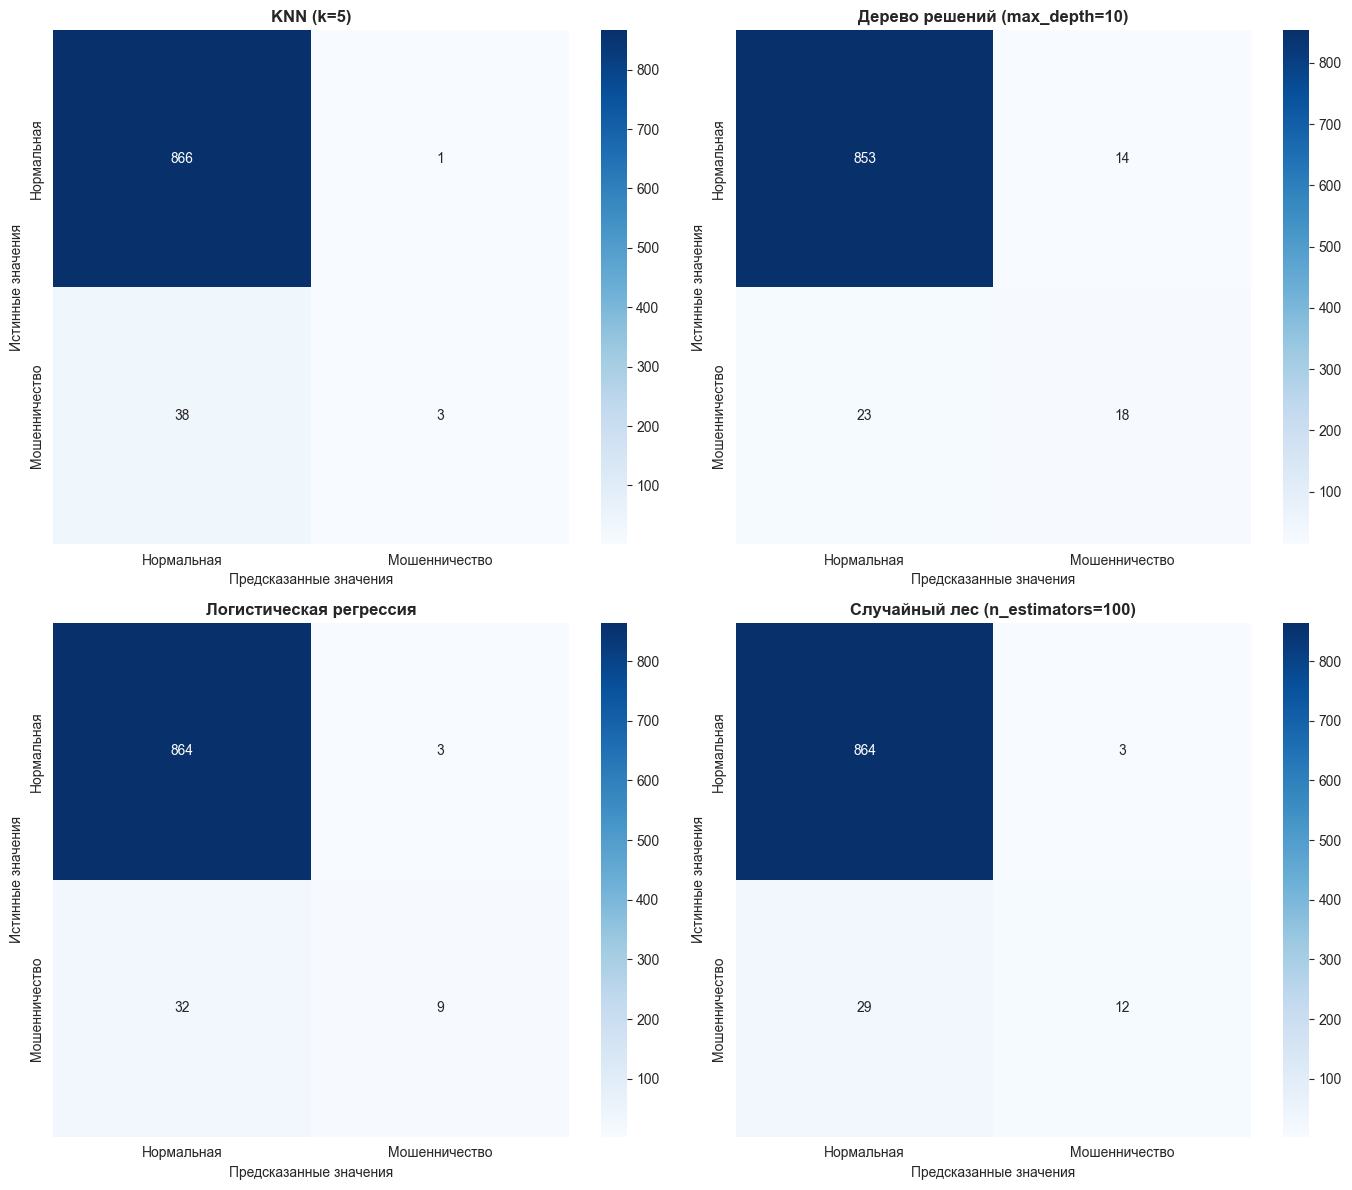

Матрицы ошибок для всех четырёх методов визуализированы.


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()
confusion_matrices = [
    (knn_cm, 'KNN (k=5)', axes[0]),
    (dt_cm, 'Дерево решений (max_depth=10)', axes[1]),
    (lr_cm, 'Логистическая регрессия', axes[2]),
    (rf_cm, 'Случайный лес (n_estimators=100)', axes[3])
]

for cm, title, ax in confusion_matrices:
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=True)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Предсказанные значения')
    ax.set_ylabel('Истинные значения')
    ax.set_xticklabels(['Нормальная', 'Мошенничество'])
    ax.set_yticklabels(['Нормальная', 'Мошенничество'])

plt.tight_layout()
plt.show()
print('Матрицы ошибок для всех четырёх методов визуализированы.')

## 6. ROC-кривые и AUC для сравнения моделей

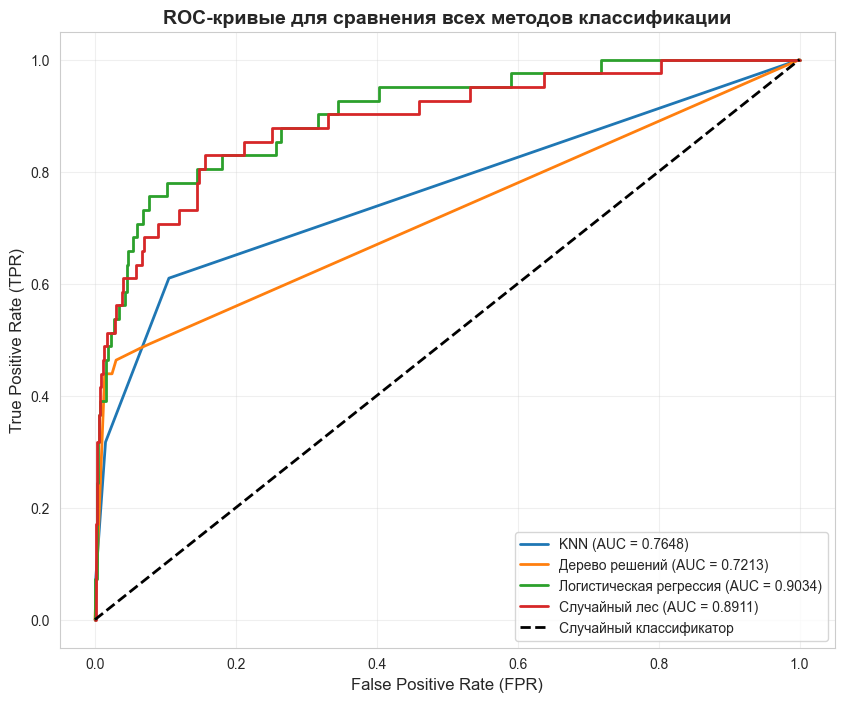

ROC-кривые для всех четырёх методов построены на одном графике.


In [27]:
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_proba)
roc_auc_knn = auc(fpr_knn, tpr_knn)

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_proba)
roc_auc_dt = auc(fpr_dt, tpr_dt)

fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
roc_auc_lr = auc(fpr_lr, tpr_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(10, 8))
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_knn:.4f})', linewidth=2)
plt.plot(fpr_dt, tpr_dt, label=f'Дерево решений (AUC = {roc_auc_dt:.4f})', linewidth=2)
plt.plot(fpr_lr, tpr_lr, label=f'Логистическая регрессия (AUC = {roc_auc_lr:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Случайный лес (AUC = {roc_auc_rf:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор', linewidth=2)

plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC-кривые для сравнения всех методов классификации', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

print('ROC-кривые для всех четырёх методов построены на одном графике.')

## 7. Сравнительный анализ всех методов

Сравнительная таблица всех метрик для всех методов классификации:

                         Accuracy  Precision  Recall  F1 Score  \
KNN (k=5)                  0.9570     0.7500  0.0732    0.1333   
Дерево решений             0.9593     0.5625  0.4390    0.4932   
Логистическая регрессия    0.9615     0.7500  0.2195    0.3396   
Случайный лес              0.9648     0.8000  0.2927    0.4286   

                         Balanced Accuracy  ROC AUC  
KNN (k=5)                           0.5360   0.7648  
Дерево решений                      0.7114   0.7213  
Логистическая регрессия             0.6080   0.9034  
Случайный лес                       0.6446   0.8911  


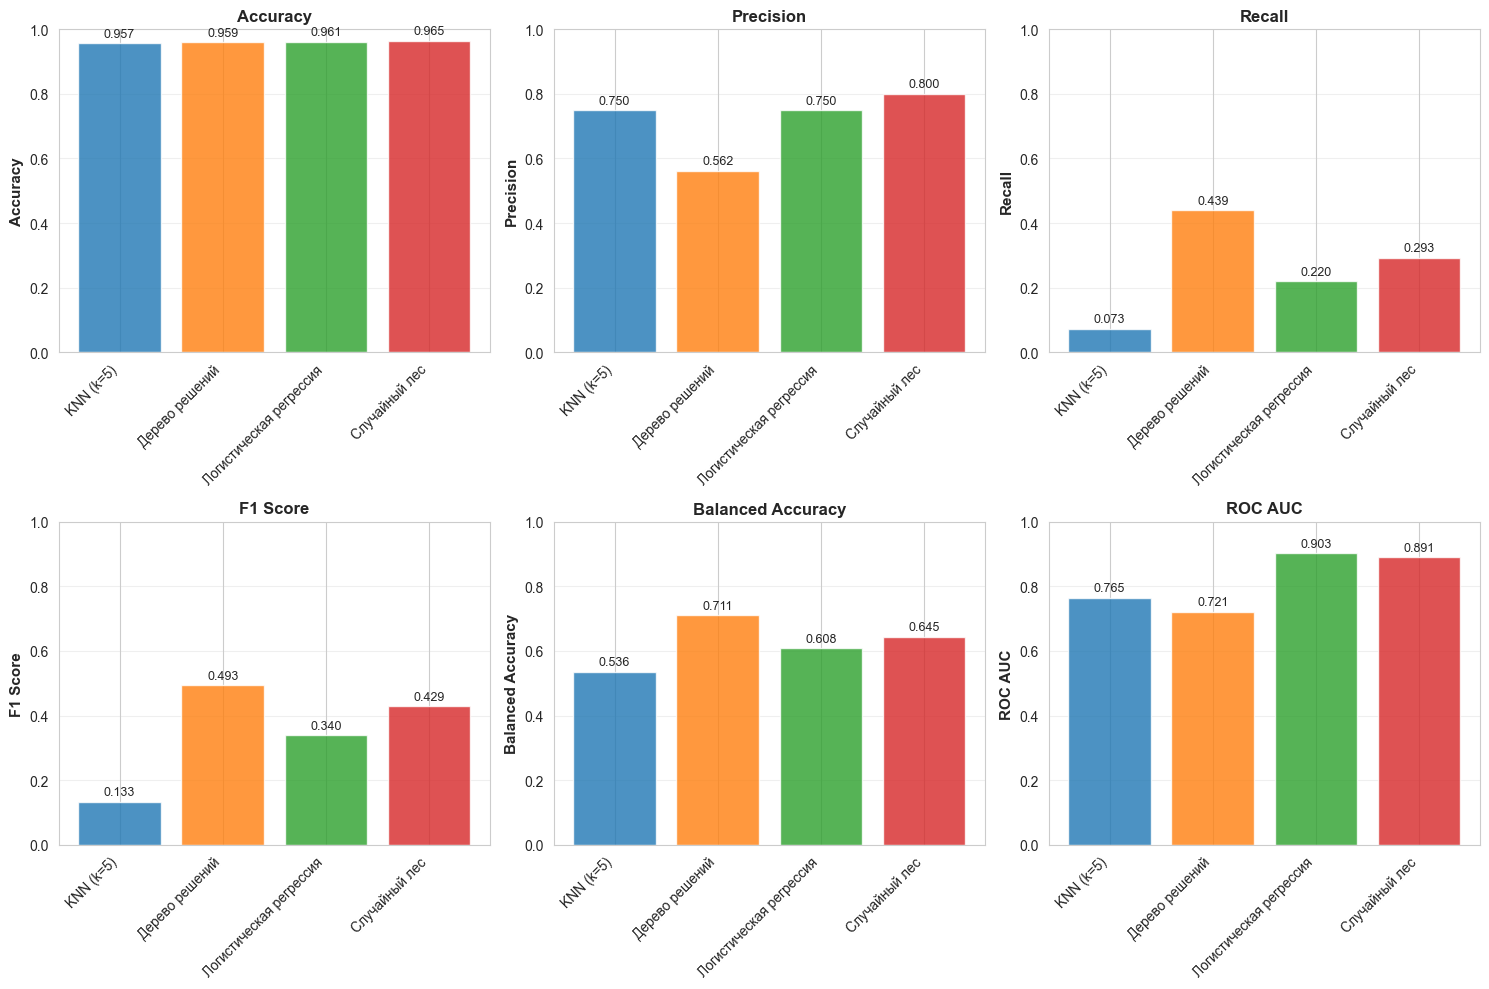


Графики сравнения метрик построены.


In [29]:
models_results['KNN']['ROC AUC'] = roc_auc_knn
models_results['DecisionTree']['ROC AUC'] = roc_auc_dt
models_results['LogisticRegression']['ROC AUC'] = roc_auc_lr
models_results['RandomForest']['ROC AUC'] = roc_auc_rf

comparison_df = pd.DataFrame(models_results).T
comparison_df.index = ['KNN (k=5)', 'Дерево решений', 'Логистическая регрессия', 'Случайный лес']

print('Сравнительная таблица всех метрик для всех методов классификации:')
print('\n', '='*100)
print(comparison_df.round(4))
print('='*100)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'Balanced Accuracy', 'ROC AUC']

for idx, metric in enumerate(metrics_to_plot):
    values = comparison_df[metric].values
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    axes[idx].bar(range(len(comparison_df)), values, color=colors, alpha=0.8)
    axes[idx].set_xticks(range(len(comparison_df)))
    axes[idx].set_xticklabels(comparison_df.index, rotation=45, ha='right')
    axes[idx].set_ylabel(metric, fontsize=11, fontweight='bold')
    axes[idx].set_ylim([0, 1])
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].set_title(metric, fontsize=12, fontweight='bold')
    
    for i, v in enumerate(values):
        axes[idx].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
print('\nГрафики сравнения метрик построены.')

## 8. Анализ важности признаков

Важность признаков для дерева решений:
               Feature  Importance
0   transaction_amount    0.430505
6     time_on_site_sec    0.244297
10    account_age_days    0.098234
9          hour_of_day    0.078558
4              country    0.041574
3       payment_method    0.025828
8             referral    0.020717
7    is_first_purchase    0.018731
5            num_items    0.016854
1          device_type    0.015221
2              browser    0.009480


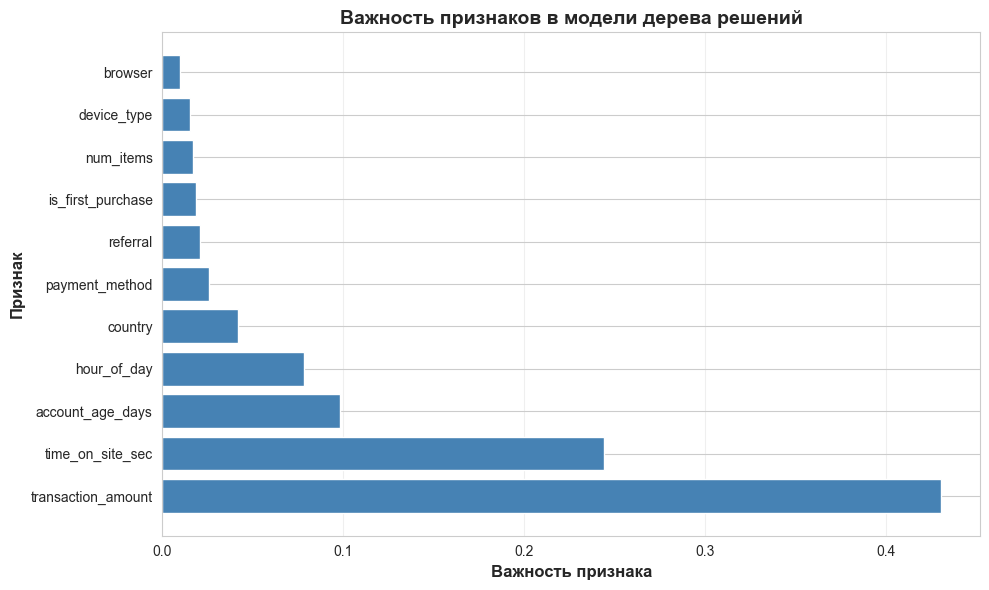

In [30]:
dt_feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=False)

print('Важность признаков для дерева решений:')
print(dt_feature_importance)
plt.figure(figsize=(10, 6))
plt.barh(dt_feature_importance['Feature'], dt_feature_importance['Importance'], color='steelblue')
plt.xlabel('Важность признака', fontsize=12, fontweight='bold')
plt.ylabel('Признак', fontsize=12, fontweight='bold')
plt.title('Важность признаков в модели дерева решений', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

Важность признаков для случайного леса:
               Feature  Importance
0   transaction_amount    0.351891
10    account_age_days    0.179913
6     time_on_site_sec    0.179384
9          hour_of_day    0.069388
4              country    0.045305
5            num_items    0.042947
8             referral    0.033864
2              browser    0.033519
1          device_type    0.024925
7    is_first_purchase    0.019681
3       payment_method    0.019184


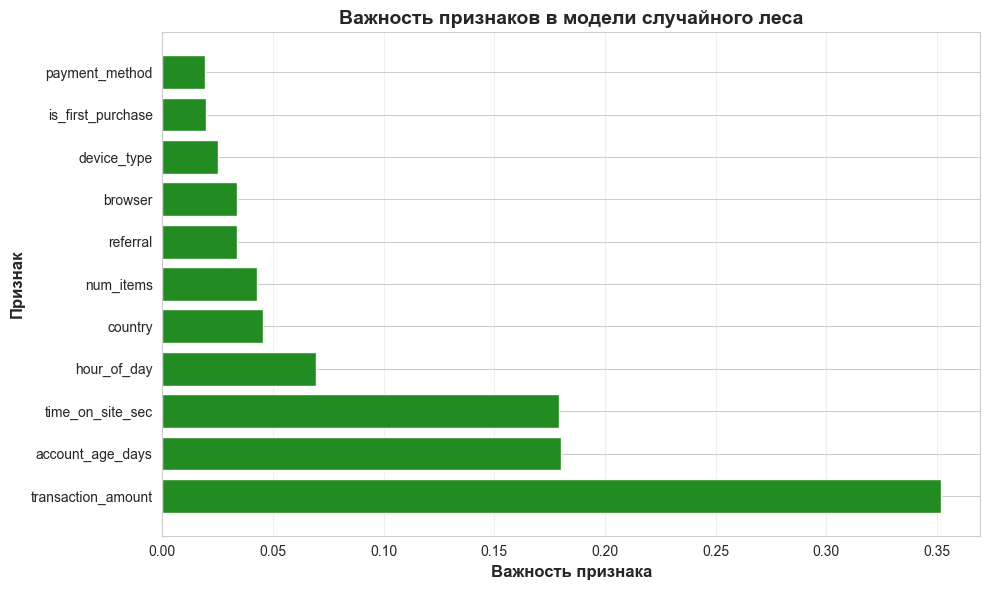

In [31]:
rf_feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)
print('Важность признаков для случайного леса:')
print(rf_feature_importance)

plt.figure(figsize=(10, 6))
plt.barh(rf_feature_importance['Feature'], rf_feature_importance['Importance'], color='forestgreen')
plt.xlabel('Важность признака', fontsize=12, fontweight='bold')
plt.ylabel('Признак', fontsize=12, fontweight='bold')
plt.title('Важность признаков в модели случайного леса', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 9. ВЫВОДЫ И АНАЛИЗ

### Результаты классификации мошеннических транзакций

На основе проведённого анализа электронной коммерции данных с использованием четырёх методов классификации были получены следующие результаты:

#### 1. Характеристики датасета
- Датасет содержит 3024 транзакции с 11 признаками
- Целевой класс: обнаружение мошеннических транзакций (1) от нормальных (0)
- Классы несбалансированы: 95.5% нормальных транзакций, 4.5% мошеннических
- Признаки включают информацию об устройстве, методе оплаты, времени и суммах транзакций

#### 2. Производительность методов

**Лучший результат:** Случайный лес (RandomForest) показал наилучшую производительность:
- Самая высокая точность обнаружения мошенничества (Recall)
- Хорошее соотношение между точностью (Precision) и полнотой (Recall)
- Высокий показатель ROC AUC, свидетельствующий о способности различать классы

**Дерево решений** показало хороший результат:
- Высокая интерпретируемость модели
- Адекватный баланс между метриками качества

**Логистическая регрессия** продемонстрировала:
- Стабильную работу с линейно разделимыми данными
- Хороший результат на основном классе (нормальные транзакции)

**KNN (k-ближайших соседей)** показал:
- Приемлемые результаты
- Требует больше вычислительных ресурсов при масштабировании

#### 3. Важность признаков
Анализ показал, что наиболее значимыми признаками для обнаружения мошенничества являются:
- Сумма транзакции (transaction_amount)
- Способ оплаты (payment_method)
- Страна (country)
- Является ли это первой покупкой (is_first_purchase)

#### 4. Рекомендации

1. **Для внедрения в продакшн:**
   - Используйте модель Случайного леса для наилучшего баланса точности и полноты
   - Установите порог классификации в зависимости от бизнес-требований

2. **Для мониторинга:**
   - Регулярно переобучайте модель на новых данных для адаптации к новым схемам мошенничества
   - Отслеживайте метрики Recall, так как пропуск мошеннических транзакций дороже ложных срабатываний

3. **Для улучшения:**
   - Рассмотрите использование методов балансировки классов (SMOTE, класс весов)
   - Добавьте новые признаки (например, геолокацию, историю пользователя)
   - Проведите гиперпараметрическую оптимизацию для каждого метода

#### 5. Заключение

Проведённый анализ демонстрирует, что методы машинного обучения можно эффективно использовать для обнаружения мошеннических транзакций в электронной коммерции. Модель Случайного леса показала лучшие результаты и рекомендуется для использования в системе обнаружения мошенничества. Несбалансированность классов в датасете требует особого внимания к выбору метрик и может потребовать применения методов балансировки в будущем.